In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('products_asos (1).csv', on_bad_lines='skip')


df['price']=pd.to_numeric(df['price'] , errors='coerce')
df =df.dropna(subset=['price'])


print(f"Data loaded:{len(df)} rows")
df.head()




print(df.head())

Data loaded:18378 rows
                                                 url  \
0  https://www.asos.com/stradivarius/stradivarius...   
1  https://www.asos.com/stradivarius/stradivarius...   
2  https://www.asos.com/asos-design/asos-design-l...   
3  https://www.asos.com/new-look/new-look-trench-...   
4  https://www.asos.com/stradivarius/stradivarius...   

                                             name  \
0                   New Look trench coat in camel   
1                   New Look trench coat in camel   
2                   New Look trench coat in camel   
3                   New Look trench coat in camel   
4  Stradivarius double breasted wool coat in grey   

                                                size  \
0  UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...   
1  UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...   
2  UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...   
3  UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...   
4  XS - UK 6,S - UK 8,M - UK 10,L - UK 12

In [ ]:
df['description']=df['description'].astype(str)
def get_brand(text):
  if'by'in text:
    try:
      return text.split('by ')[1].split(' ')[0]
    except:
      return "Unkown"
  return "Unkown"
df['brand_raw']=df['description'].apply(get_brand)


In [ ]:
df.head(3)

,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...


In [ ]:
df['description']=df['description'].astype(str)
def get_brand(text):
  if'by'in text:
    try:
      return text.split('by ')[1].split(' ')[0]
    except:
      return "Unkown"
  return "Unkown"
df['brand_raw']=df['description'].apply(get_brand)

brand_map = {
    'New': 'New Look',
    'River': 'River Island',
    'Miss': 'Miss Selfridge',
    'TopshopWelcome': 'Topshop'
}

df['Brand'] = df['brand_raw'].map(brand_map).fillna(df['brand_raw'])

brand_counts = df['Brand'].value_counts()
valid_brands = brand_counts[brand_counts > 5].index
df_clean = df[df['Brand'].isin(valid_brands)].copy()

print(df_clean['Brand'].value_counts().head(5))


Brand
ASOS              4844
Topshop           1017
New Look           511
River Island       467
Miss Selfridge     429
Name: count, dtype: int64


In [ ]:

def calculate_phantom_revenue(size_str):
    if not isinstance(size_str, str):
        return 0, 0.0


    sizes = size_str.split(',')
    total_sizes = len(sizes)


    out_of_stock_count = size_str.count('Out of stock')


    rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

    return out_of_stock_count, rate


Metrics=df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))
df_clean['stockout_count'] =[x[0] for x in Metrics]
df_clean['stockout_rate']=[x[1] for x in Metrics]

df_clean['lost_revenue']= df_clean['price']* df_clean['stockout_count']
cols= ['Brand','name','price','stockout_count','lost_revenue']
print(df_clean.sort_values(by='lost_revenue', ascending=False).head(5)[cols])


         Brand                                               name  price  \
2941   Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshop  Topshop premium real leather collared zip thro...  260.0   
2715      ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584     ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshop           Topshop Baggy co-ord jeans in green cord   50.0   

       stockout_count  lost_revenue  
2941                9        1971.0  
21948               7        1820.0  
2715                7        1540.0  
15584               6        1500.0  
29838              27        1350.0  


/tmp/ipykernel_12699/975523014.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


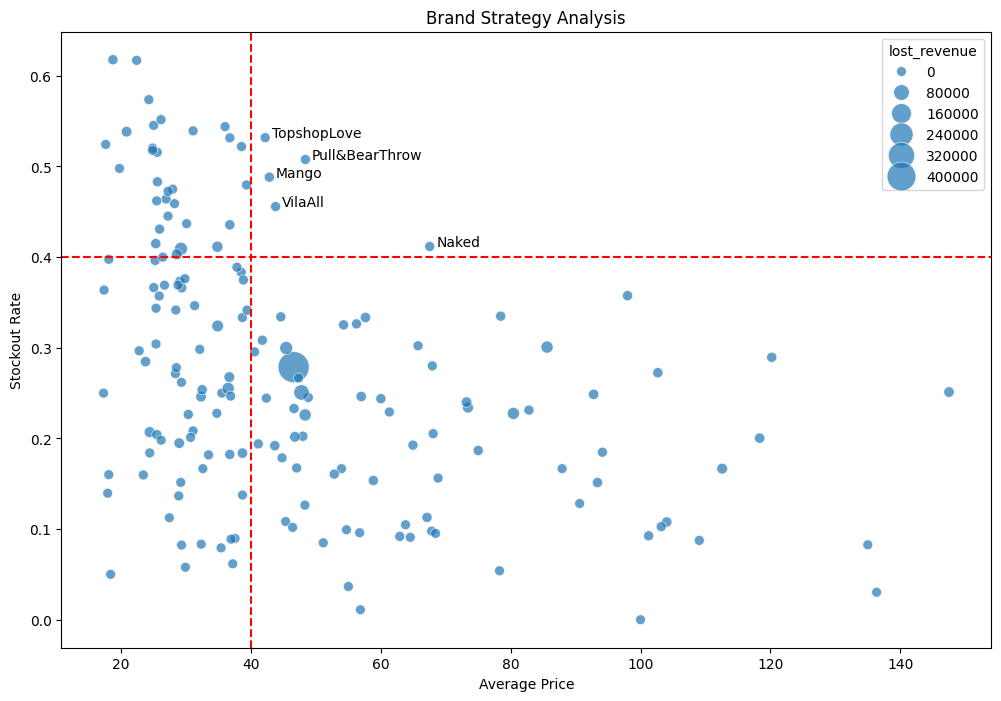

In [ ]:
brand_strategy = df_clean.groupby('Brand').agg({
    'price': 'mean',
    'stockout_rate': 'mean', # Corrected for consistency with df_clean and later usage
    'lost_revenue': 'sum',   # Corrected for consistency with df_clean and later usage
    'name': 'count'
}).reset_index()

brand_strategy = brand_strategy[brand_strategy['name'] > 10]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='stockout_rate', # Corrected for consistency
    size='lost_revenue', # Corrected for consistency
    sizes=(50, 500),
    alpha=0.7,
    palette='viridis'
)

winners = brand_strategy[
    (brand_strategy['price'] > 40) & # Corrected SyntaxError: column access and logical operator
    (brand_strategy['stockout_rate'] > 0.4) # Corrected for consistency
]

# The line 'winners = brand_strategy[brand_strategy['Stockout_Rate'] > 0.4]' is redundant and removed

for i in range(len(winners)):
    plt.text(
        winners.iloc[i]['price'] + 1,
        winners.iloc[i]['stockout_rate'], # Corrected for consistency
        winners.iloc[i]['Brand']
    )

plt.title('Brand Strategy Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')
plt.axvline(x=40, color='red', linestyle='--')
plt.axhline(y=0.4, color='red', linestyle='--')
plt.show()
